# Create PWHL Attendance Dataset

[PWHL Data reference](https://github.com/IsabelleLefebvre97/PWHL-Data-Reference)

> Add blockquote



In [34]:
pip install requests

In [35]:
import pandas as pd

In [36]:
import requests
def get_game_summary_df_from_id(game_id):
  game_summary_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=gc&tab=gamesummary&game_id="+str(game_id)+"&key=446521baf8c38984&client_code=pwhl")
  # print(response.status_code)

  game_summary_data = game_summary_response.json()
  game_summary_json = game_summary_data["GC"]["Gamesummary"]["meta"]

  # Load the JSON file into a DataFrame
  game_summary_df = pd.json_normalize(game_summary_json)

  game_summary_df_attendance_df = game_summary_df[["id","season_id", "home_team", "visiting_team", "game_number", "attendance", "location", "date_played"]]
  return game_summary_df_attendance_df

In [37]:
team_name_map = {
    1: "Boston Fleet",
    2: "Minnesota Frost",
    3: "Montréal Victoire",
    4: "New York Sirens",
    5: "Ottawa Charge",
    6: "Toronto Sceptres",
    8: "Seattle Torrent",
    9: "Vancouver Goldeneyes",
}

primary_location_name_map = {
    29: "Grand Casino Arena",
    30: "Pacific Coliseum",
    1: "TD Place",
    3: "Tsongas Center",
    8: "Place Bell",
    17: "Coca-Cola Coliseum",
    16: "Prudential Center",
    21: "Climate Pledge Arena"
}

all_location_name_map = {
    **primary_location_name_map,
    23: "Ball Arena",
    28: "Agganis Arena",
    # TODO
}


def format_game_summary_df(game_summary_df):
  game_summary_df_formatted = game_summary_df.copy()
  game_summary_df_formatted["id"] = game_summary_df_formatted["id"].astype(int)
  game_summary_df_formatted["home_team"] = game_summary_df_formatted["home_team"].astype(int)
  game_summary_df_formatted["visiting_team"] = game_summary_df_formatted["visiting_team"].astype(int)
  game_summary_df_formatted["season_id"] = game_summary_df_formatted["season_id"].astype(int)
  game_summary_df_formatted["game_number"] = game_summary_df_formatted["game_number"].astype(int)
  game_summary_df_formatted["attendance"] = game_summary_df_formatted["attendance"].astype(int)
  game_summary_df_formatted["location"] = game_summary_df_formatted["location"].astype(int)
  game_summary_df_formatted["home_team_name"] = game_summary_df_formatted["home_team"].map(team_name_map)
  game_summary_df_formatted["visiting_team_name"] = game_summary_df_formatted["visiting_team"].map(team_name_map)
  game_summary_df_formatted["location_name"] = game_summary_df_formatted["location"].map(primary_location_name_map)
  return game_summary_df_formatted


In [38]:
def get_attendance_data_between_ids_inclusive_exclusive(start_game_id, end_game_id):
  primary_venue_dfs = []
  special_venue_dfs = []
  for game_id in range(start_game_id, end_game_id):
    temp_df = get_game_summary_df_from_id(game_id)
    # Only filter for non takeover games
    if len(temp_df) == 1:
      location = temp_df["location"].iloc[0]
      if int(location) in primary_location_name_map:
        primary_venue_dfs.append(temp_df)
      else:
        special_venue_dfs.append(temp_df)
  primary_venue_games = pd.concat(primary_venue_dfs, ignore_index=True)
  special_venue_games = pd.concat(special_venue_dfs, ignore_index=True)
  return format_game_summary_df(primary_venue_games), format_game_summary_df(special_venue_games)

In [39]:
S3_FIRST_GAME_ID = 210
S3_LAST_GAME_ID = 329

In [40]:
primary_venue_attendance_data, special_venue_attendance_data = get_attendance_data_between_ids_inclusive_exclusive(S3_FIRST_GAME_ID, S3_LAST_GAME_ID + 1)
# primary_venue_attendance_data, special_venue_attendance_data = get_attendance_data_between_ids_inclusive_exclusive(235, 340)

In [41]:
primary_venue_attendance_data

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
0,210,8,2,6,1,9138,29,2025-11-21,Minnesota Frost,Toronto Sceptres,Grand Casino Arena
1,211,8,9,8,2,14958,30,2025-11-21,Vancouver Goldeneyes,Seattle Torrent,Pacific Coliseum
2,212,8,5,4,3,7371,1,2025-11-22,Ottawa Charge,New York Sirens,TD Place
3,213,8,1,3,4,5166,3,2025-11-23,Boston Fleet,Montréal Victoire,Tsongas Center
4,214,8,3,4,5,8392,8,2025-11-25,Montréal Victoire,New York Sirens,Place Bell
...,...,...,...,...,...,...,...,...,...,...,...
90,325,8,8,2,116,11982,21,2026-04-22,Seattle Torrent,Minnesota Frost,Climate Pledge Arena
91,326,8,8,3,117,17151,21,2026-04-25,Seattle Torrent,Montréal Victoire,Climate Pledge Arena
92,327,8,9,2,118,11310,30,2026-04-25,Vancouver Goldeneyes,Minnesota Frost,Pacific Coliseum
93,328,8,5,6,119,8306,1,2026-04-25,Ottawa Charge,Toronto Sceptres,TD Place


In [42]:
special_venue_attendance_data

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
0,220,8,1,9,11,3516,28,2025-12-03,Boston Fleet,Vancouver Goldeneyes,NaN
1,225,8,1,2,16,5338,28,2025-12-07,Boston Fleet,Minnesota Frost,NaN
2,227,8,6,3,18,10438,32,2025-12-17,Toronto Sceptres,Montréal Victoire,NaN
3,233,8,2,5,24,7238,33,2025-12-21,Minnesota Frost,Ottawa Charge,NaN
4,238,8,3,6,29,18107,15,2025-12-27,Montréal Victoire,Toronto Sceptres,NaN
5,239,8,9,2,30,10264,27,2025-12-27,Vancouver Goldeneyes,Minnesota Frost,NaN
6,240,8,4,8,31,8514,34,2025-12-28,New York Sirens,Seattle Torrent,NaN
7,245,8,6,8,36,16012,35,2026-01-03,Toronto Sceptres,Seattle Torrent,NaN
8,246,8,1,9,37,9624,9,2026-01-03,Boston Fleet,Vancouver Goldeneyes,NaN
9,250,8,1,8,41,6003,28,2026-01-07,Boston Fleet,Seattle Torrent,NaN


In [43]:
average_attendance_by_location = primary_venue_attendance_data.groupby('location_name')['attendance'].mean().reset_index()
print(average_attendance_by_location)

          location_name    attendance
0  Climate Pledge Arena  12875.461538
1    Coca-Cola Coliseum   8379.583333
2    Grand Casino Arena   8142.846154
3      Pacific Coliseum  11234.692308
4            Place Bell   9270.583333
5     Prudential Center   4018.666667
6              TD Place   7382.000000
7        Tsongas Center   4885.250000


In [44]:
all_games = pd.concat([special_venue_attendance_data, primary_venue_attendance_data])

In [55]:
# There should be 120 games
len(all_games)

120

In [45]:
average_attendance_by_team = all_games.groupby('home_team_name')['attendance'].mean().reset_index()
print(average_attendance_by_team)

         home_team_name    attendance
0          Boston Fleet   6530.666667
1       Minnesota Frost   8573.800000
2     Montréal Victoire  10661.066667
3       New York Sirens   6131.466667
4         Ottawa Charge   9138.200000
5       Seattle Torrent  12599.933333
6      Toronto Sceptres   9657.400000
7  Vancouver Goldeneyes  11140.600000


I'm not sure where the discrepancy is coming from:

https://lscluster.hockeytech.com/media/pwhl/pwhl/index.php?format=HTML&season_id=8&step=4&sub=15

In [46]:
primary_venue_attendance_data.to_csv("primary_venue_attendance_data.csv")

In [47]:
special_venue_attendance_data.to_csv("special_venue_attendance_data.csv")

In [48]:
all_games.to_csv("pwhl_s3_attendance_data.csv")

In [49]:
average_attendance_by_location.to_csv("primary_venue_average_attendance_by_location.csv")

In [50]:
average_attendance_by_team.to_csv("average_attendance_by_home_team.csv")

In [78]:
df_filtered = primary_venue_attendance_data[primary_venue_attendance_data["location_name"] == "Prudential Center"]

In [79]:
df_filtered

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
7,217,8,4,9,8,3517,16,2025-11-29,New York Sirens,Vancouver Goldeneyes,Prudential Center
15,228,8,4,1,19,1884,16,2025-12-17,New York Sirens,Boston Fleet,Prudential Center
19,232,8,4,6,23,3517,16,2025-12-21,New York Sirens,Toronto Sceptres,Prudential Center
25,242,8,4,9,33,2735,16,2025-12-31,New York Sirens,Vancouver Goldeneyes,Prudential Center
26,243,8,4,3,34,3513,16,2026-01-02,New York Sirens,Montréal Victoire,Prudential Center
34,256,8,4,2,47,4244,16,2026-01-16,New York Sirens,Minnesota Frost,Prudential Center
36,260,8,4,5,51,2759,16,2026-01-20,New York Sirens,Ottawa Charge,Prudential Center
46,271,8,4,3,62,3488,16,2026-02-26,New York Sirens,Montréal Victoire,Prudential Center
53,278,8,4,1,69,3765,16,2026-03-05,New York Sirens,Boston Fleet,Prudential Center
54,279,8,4,5,70,8264,16,2026-03-08,New York Sirens,Ottawa Charge,Prudential Center


In [58]:
arena_capacities_df = pd.read_csv("pwhl_arena_capacities.csv")
arena_capacities_df.head()

,Unnamed: 0,location_name,city,capacity
0,0,Climate Pledge Arena,Seattle,17151
1,1,Coca-Cola Coliseum,Toronto,8140
2,2,Grand Casino Arena,Minnesota,18064
3,3,Pacific Coliseum,Vancouver,15041
4,4,Place Bell,Montréal,10172


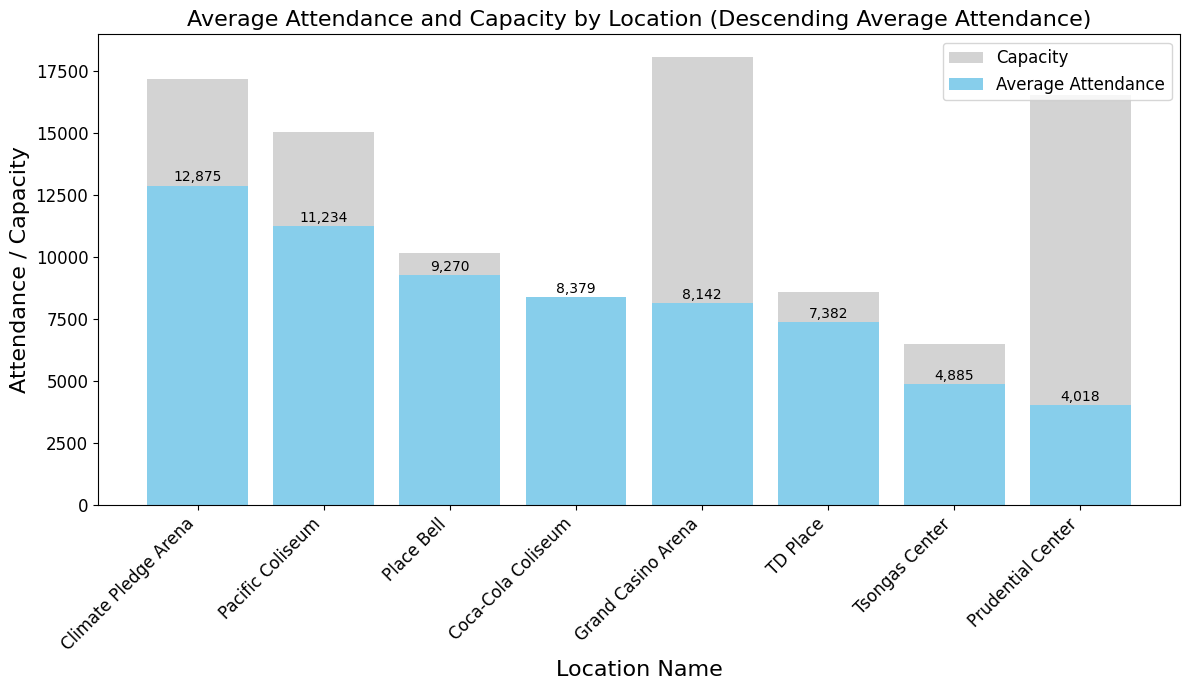

In [67]:
import matplotlib.pyplot as plt

# Assuming 'location_name' in arena_capacities_df is now clean and directly matches 'location_name' in average_attendance_by_location

# Merge average_attendance_by_location with arena_capacities_df
# Select only relevant columns from arena_capacities_df to avoid conflicts and keep 'capacity'
merged_df = pd.merge(
    average_attendance_by_location,
    arena_capacities_df[['location_name', 'capacity']], # Use original 'location_name' directly
    on='location_name', # Merge directly on 'location_name'
    how='left'
)

# Sort the DataFrame by attendance in descending order
sorted_merged_df = merged_df.sort_values(by='attendance', ascending=False)

plt.figure(figsize=(12, 7)) # Reduced figure size

# Plot capacity bars first (as background)
plt.bar(
    sorted_merged_df['location_name'],
    sorted_merged_df['capacity'],
    color='lightgray', # A lighter color for capacity
    label='Capacity'
)

# Plot average attendance bars on top
attendance_bars = plt.bar(
    sorted_merged_df['location_name'],
    sorted_merged_df['attendance'], # Using 'attendance' from average_attendance_by_location
    color='skyblue', # Original color for average attendance
    label='Average Attendance'
)

# Add attendance numbers on top of the bars
for bar in attendance_bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{int(yval):,}", ha='center', va='bottom', fontsize=10)

plt.xlabel('Location Name', fontsize=16)
plt.ylabel('Attendance / Capacity', fontsize=16)
plt.title('Average Attendance and Capacity by Location (Descending Average Attendance)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12) # Kept xtick font size as it was before, to fit better
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

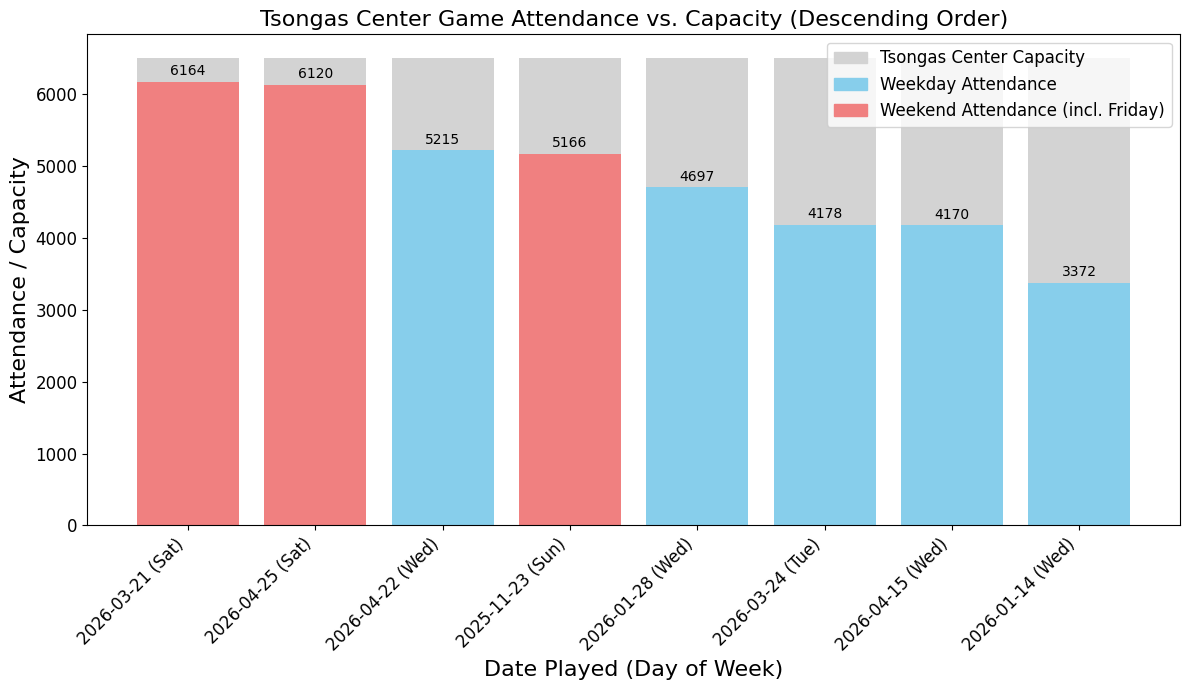

In [66]:
import matplotlib.pyplot as plt

# Filter for Tsongas Center games from primary_venue_attendance_data
tsongas_games_df = primary_venue_attendance_data[primary_venue_attendance_data['location_name'] == 'Tsongas Center'].copy()

# Convert 'date_played' to datetime objects to get day of the week
tsongas_games_df['date_played_dt'] = pd.to_datetime(tsongas_games_df['date_played'])

# Sort by attendance in descending order
tsongas_games_df_sorted = tsongas_games_df.sort_values(by='attendance', ascending=False)

# Get Tsongas Center capacity
tsongas_capacity = arena_capacities_df[arena_capacities_df['location_name'] == 'Tsongas Center']['capacity'].iloc[0]

# Create a list of game labels for the x-axis using date_played and day of week
game_labels = [f"{dt.strftime('%Y-%m-%d')} ({dt.strftime('%a')})" for dt in tsongas_games_df_sorted['date_played_dt']]

# Determine colors based on weekday/weekend (Friday now included in weekend)
# Monday=0, Sunday=6. Fri=4. So, dayofweek >= 4 includes Friday, Saturday, Sunday.
colors = ['lightcoral' if day_dt.dayofweek >= 4 else 'skyblue' for day_dt in tsongas_games_df_sorted['date_played_dt']]

plt.figure(figsize=(12, 7))

# Plot capacity bars first (as background)
plt.bar(
    game_labels,
    [tsongas_capacity] * len(tsongas_games_df_sorted),
    color='lightgray',
    label='Tsongas Center Capacity'
)

# Plot attendance bars on top with conditional coloring
attendance_bars = plt.bar(
    game_labels,
    tsongas_games_df_sorted['attendance'],
    color=colors,
    label='Game Attendance (Weekday/Weekend)'
)

# Add attendance numbers on top of the bars
for bar in attendance_bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

plt.xlabel('Date Played (Day of Week)', fontsize=16)
plt.ylabel('Attendance / Capacity', fontsize=16)
plt.title('Tsongas Center Game Attendance vs. Capacity (Descending Order)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Create custom legend handles for weekday/weekend
weekday_patch = plt.matplotlib.patches.Patch(color='skyblue', label='Weekday Attendance')
weekend_patch = plt.matplotlib.patches.Patch(color='lightcoral', label='Weekend Attendance (incl. Friday)')
capacity_patch = plt.matplotlib.patches.Patch(color='lightgray', label='Tsongas Center Capacity')
plt.legend(handles=[capacity_patch, weekday_patch, weekend_patch], fontsize=12)

plt.tight_layout()
plt.show()

In [73]:
import matplotlib.pyplot as plt

def plot_arena_attendance_vs_capacity(arena_name, primary_venue_attendance_data, arena_capacities_df):
    # Filter for games from the specified arena
    arena_games_df = primary_venue_attendance_data[primary_venue_attendance_data['location_name'] == arena_name].copy()

    if arena_games_df.empty:
        print(f"No data found for {arena_name}.")
        return

    # Convert 'date_played' to datetime objects to get day of the week
    arena_games_df['date_played_dt'] = pd.to_datetime(arena_games_df['date_played'])

    # Sort by attendance in descending order
    arena_games_df_sorted = arena_games_df.sort_values(by='attendance', ascending=False)

    # Get arena capacity
    arena_capacity = arena_capacities_df[arena_capacities_df['location_name'] == arena_name]['capacity'].iloc[0]

    # Create a list of game labels for the x-axis using date_played and day of week
    game_labels = [f"{dt.strftime('%Y-%m-%d')} ({dt.strftime('%a')})" for dt in arena_games_df_sorted['date_played_dt']]

    # Determine colors based on weekday/weekend (Friday now included in weekend)
    # Monday=0, Sunday=6. Fri=4. So, dayofweek >= 4 includes Friday, Saturday, Sunday.
    colors = ['lightcoral' if day_dt.dayofweek >= 4 else 'skyblue' for day_dt in arena_games_df_sorted['date_played_dt']]

    plt.figure(figsize=(12, 7))

    # Plot capacity bars first (as background)
    plt.bar(
        game_labels,
        [arena_capacity] * len(arena_games_df_sorted),
        color='lightgray',
        label=f'{arena_name} Capacity'
    )

    # Plot attendance bars on top with conditional coloring
    attendance_bars = plt.bar(
        game_labels,
        arena_games_df_sorted['attendance'],
        color=colors,
        label='Game Attendance (Weekday/Weekend)'
    )

    # Add attendance numbers on top of the bars
    for bar in attendance_bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

    plt.xlabel('Date Played (Day of Week)', fontsize=16)
    plt.ylabel('Attendance / Capacity', fontsize=16)
    plt.title(f'{arena_name} Game Attendance vs. Capacity', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # Create custom legend handles for weekday/weekend
    weekday_patch = plt.matplotlib.patches.Patch(color='skyblue', label='Weekday Attendance')
    weekend_patch = plt.matplotlib.patches.Patch(color='lightcoral', label='Weekend Attendance (incl. Friday)')
    capacity_patch = plt.matplotlib.patches.Patch(color='lightgray', label=f'{arena_name} Capacity')
    plt.legend(handles=[capacity_patch, weekday_patch, weekend_patch], fontsize=12)

    plt.tight_layout()
    plt.show()

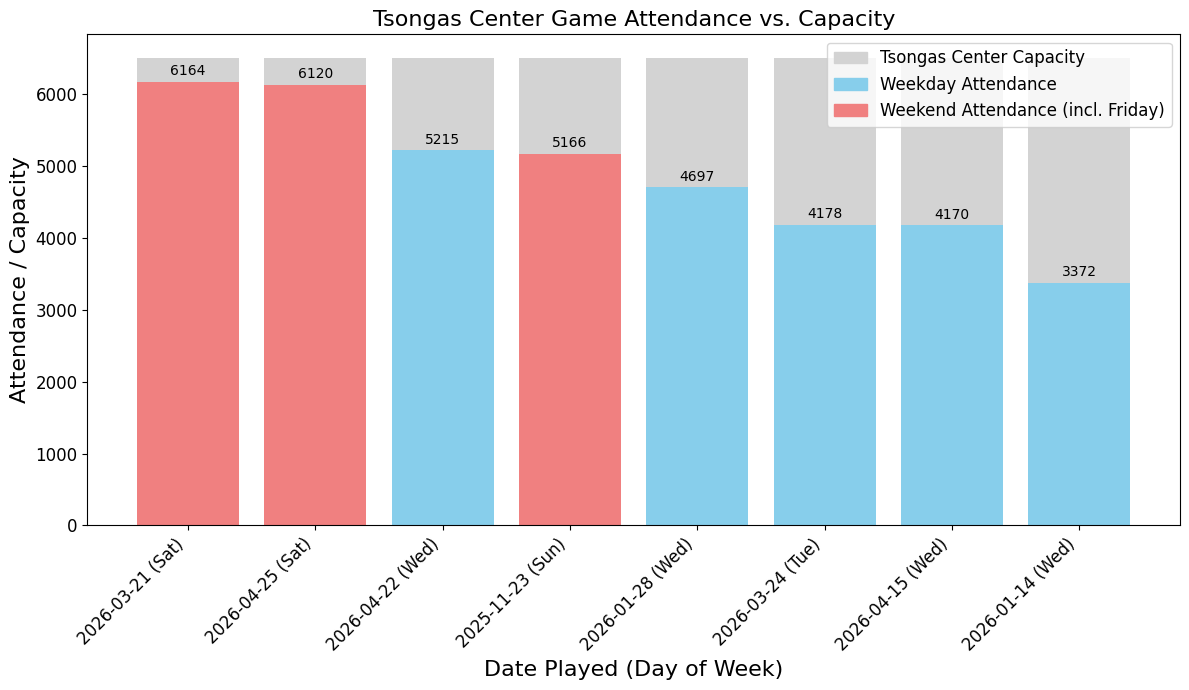

In [74]:
plot_arena_attendance_vs_capacity('Tsongas Center', primary_venue_attendance_data, arena_capacities_df)

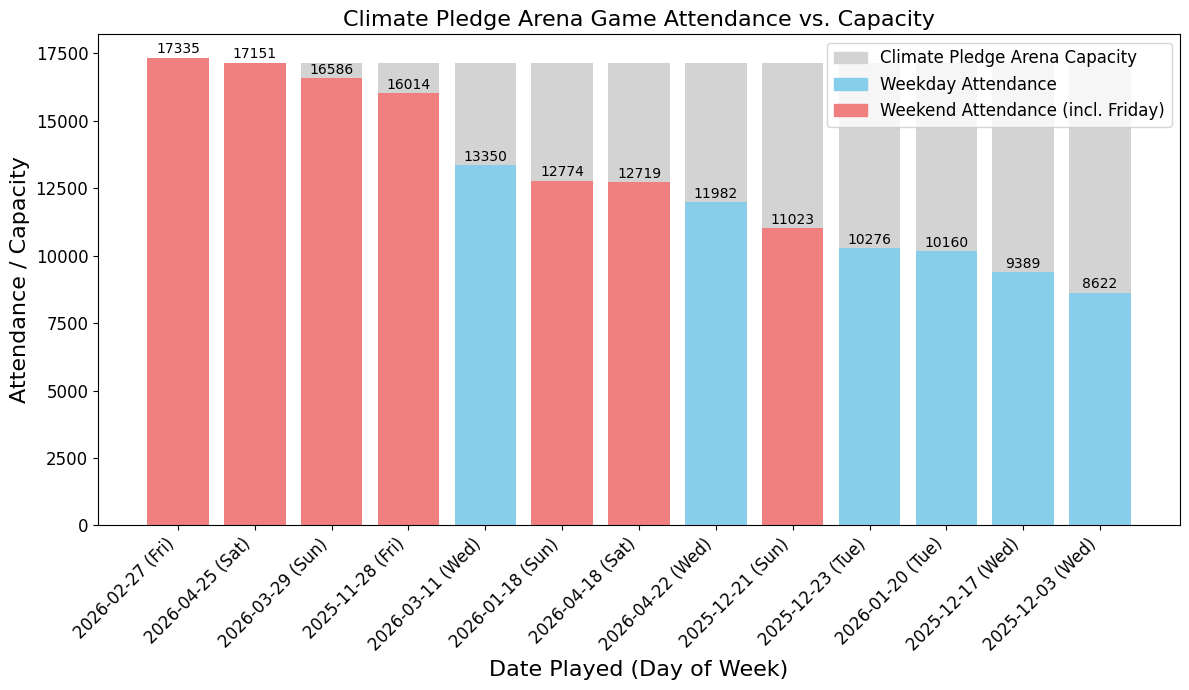

In [75]:
plot_arena_attendance_vs_capacity('Climate Pledge Arena', primary_venue_attendance_data, arena_capacities_df)

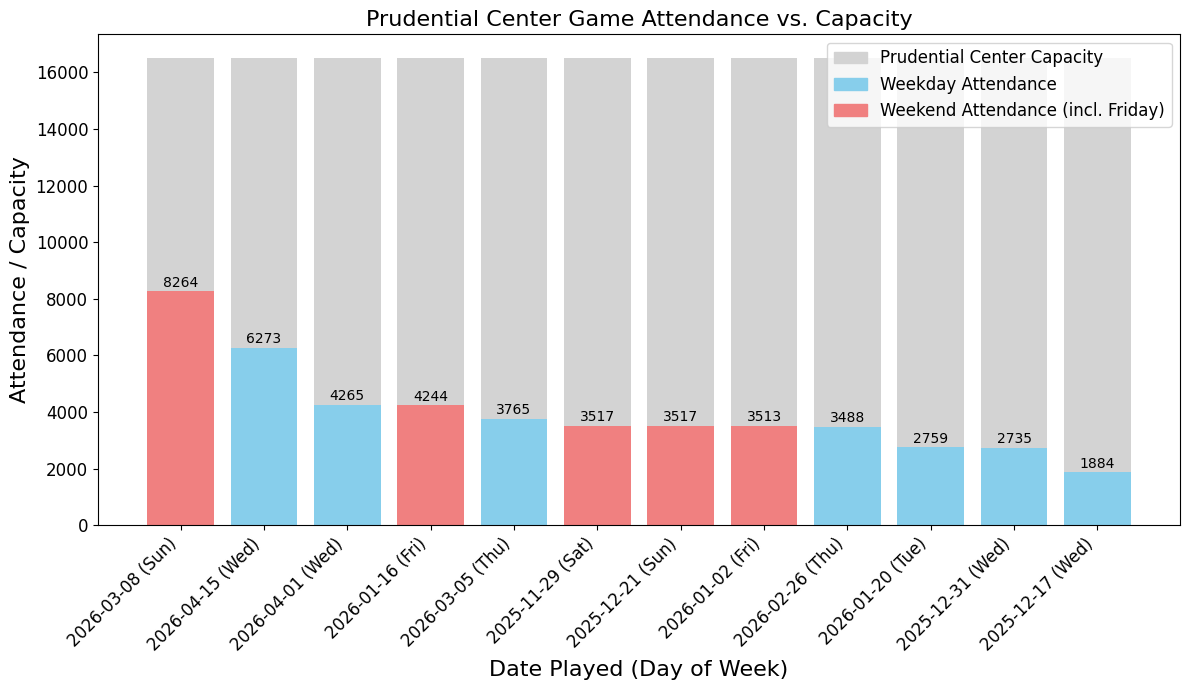

In [77]:
plot_arena_attendance_vs_capacity('Prudential Center', primary_venue_attendance_data, arena_capacities_df)